In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

# Görselleştirme ayarları
sns.set(style="whitegrid")
%matplotlib inline

# Veriyi yükle
df = pd.read_csv('dataset/ResearchInformation3.csv')

# İlk 5 satırı incele
df.head()

,Department,Gender,HSC,SSC,Income,Hometown,Computer,Preparation,Gaming,Attendance,Job,English,Extra,Semester,Last,Overall
0,Business Administration,Male,4.17,4.84,"Low (Below 15,000)",Village,3,More than 3 Hours,0-1 Hour,80%-100%,No,3,Yes,6th,3.220,3.350
1,Business Administration,Female,4.92,5.00,"Upper middle (30,000-50,000)",City,3,0-1 Hour,0-1 Hour,80%-100%,No,3,Yes,7th,3.467,3.467
2,Business Administration,Male,5.00,4.83,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,More than 3 Hours,80%-100%,No,4,Yes,3rd,4.000,3.720
3,Business Administration,Male,4.00,4.50,"High (Above 50,000)",City,5,More than 3 Hours,More than 3 Hours,80%-100%,No,5,Yes,4th,3.800,3.750
4,Business Administration,Female,2.19,3.17,"Lower middle (15,000-30,000)",Village,3,0-1 Hour,2-3 Hours,80%-100%,No,3,Yes,4th,3.940,3.940


In [19]:
# 1. 'Income' sütunundaki gereksiz boşlukları temizle
df['Income'] = df['Income'].str.strip()

# 2. Sıralı (Ordinal) Değişkenleri Elle Dönüştürme
# Bu adım çok önemli, çünkü 'Low' < 'High' ilişkisini modele öğretmeliyiz.

attendance_map = {
    'Below 40%': 0, 
    '40%-59%': 1, 
    '60%-79%': 2, 
    '80%-100%': 3
}

preparation_map = {
    '0-1 Hour': 0, 
    '2-3 Hours': 1, 
    'More than 3 Hours': 2
}

# Mapping işlemini uygula
df['Attendance_Score'] = df['Attendance'].map(attendance_map)
df['Preparation_Score'] = df['Preparation'].map(preparation_map)

# 3. Diğer Kategorik Değişkenleri Otomatik Dönüştürme (Label Encoding)
le = LabelEncoder()
categorical_cols = ['Gender', 'Department', 'Income', 'Hometown', 'Gaming', 'Job', 'Extra']

for col in categorical_cols:
    df[col + '_Code'] = le.fit_transform(df[col])

# Model için kullanılacak özellikleri seç
features = ['Attendance_Score', 'Preparation_Score', 'Income_Code', 
            'Department_Code', 'HSC', 'SSC', 'English', 'Computer']
target = 'Overall'  # Hedefimiz not ortalaması (GPA)

X = df[features]
y = df[target]

print("Veri hazırlığı tamamlandı.")

Veri hazırlığı tamamlandı.


In [20]:
# Veriyi böl (Eğitim %80, Test %20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest Modelini Kur
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Tahmin yap
y_pred = model.predict(X_test)

# Sonuçları Değerlendir
print(f"Model R-Kare Skoru (Başarı Oranı): {r2_score(y_test, y_pred):.2f}")
print(f"Ortalama Hata (MSE): {mean_squared_error(y_test, y_pred):.4f}")

Model R-Kare Skoru (Başarı Oranı): 0.54
Ortalama Hata (MSE): 0.1733


C:\Users\bberk\AppData\Local\Temp\ipykernel_9288\2563909018.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Önem Düzeyi', y='Faktör', data=feature_importance, palette='viridis')


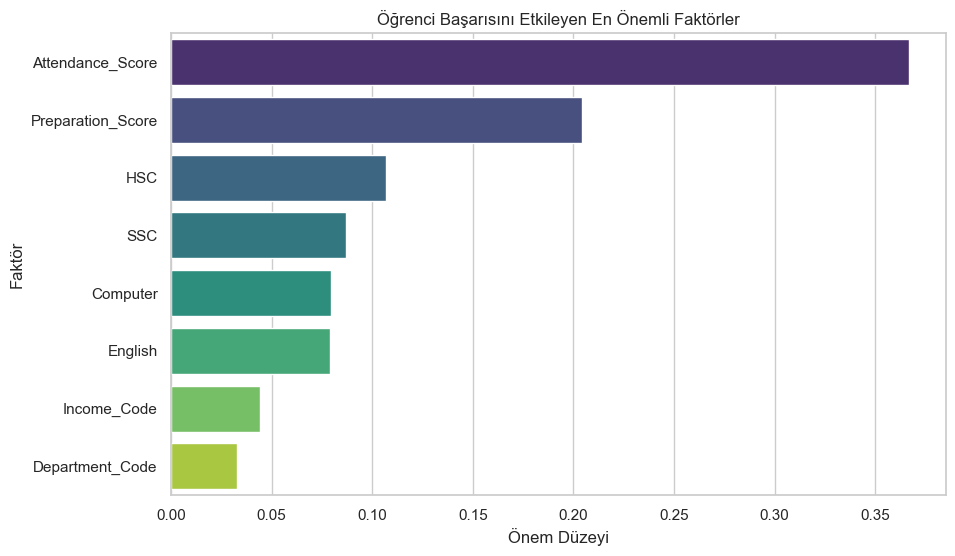

In [21]:
# Özellik Önem Düzeylerini Al
feature_importance = pd.DataFrame({
    'Faktör': features,
    'Önem Düzeyi': model.feature_importances_
}).sort_values('Önem Düzeyi', ascending=False)

# Görselleştir
plt.figure(figsize=(10, 6))
sns.barplot(x='Önem Düzeyi', y='Faktör', data=feature_importance, palette='viridis')
plt.title('Öğrenci Başarısını Etkileyen En Önemli Faktörler')
plt.show()

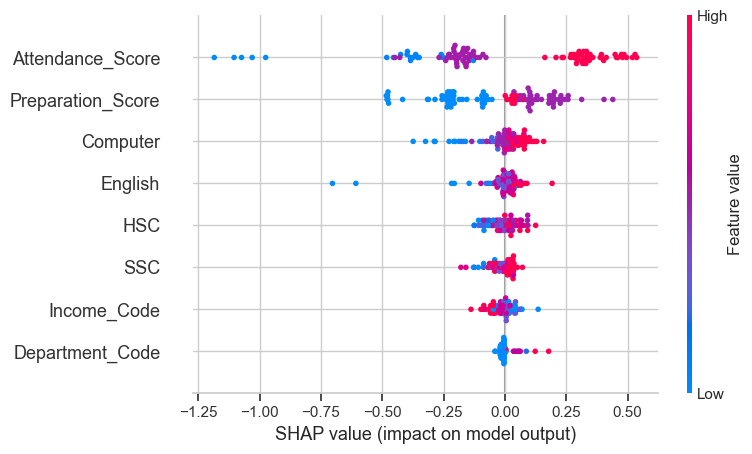

In [22]:
import shap

# 1. SHAP açıklayıcısını oluştur
explainer = shap.TreeExplainer(model) # 'model' senin eğittiğin Random Forest değişkenin
shap_values = explainer.shap_values(X_test)

# 2. Özet Grafik (Hangi özellik ne yönde etkiliyor?)
# Kırmızı noktalar özelliği yüksek (örn: çok devamsızlık), Mavi düşük gösterir.
# Eğer 'Attendance' satırında kırmızılar sol taraftaysa (negatif etki), hipotezin kanıtlanır.
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, feature_names=features)

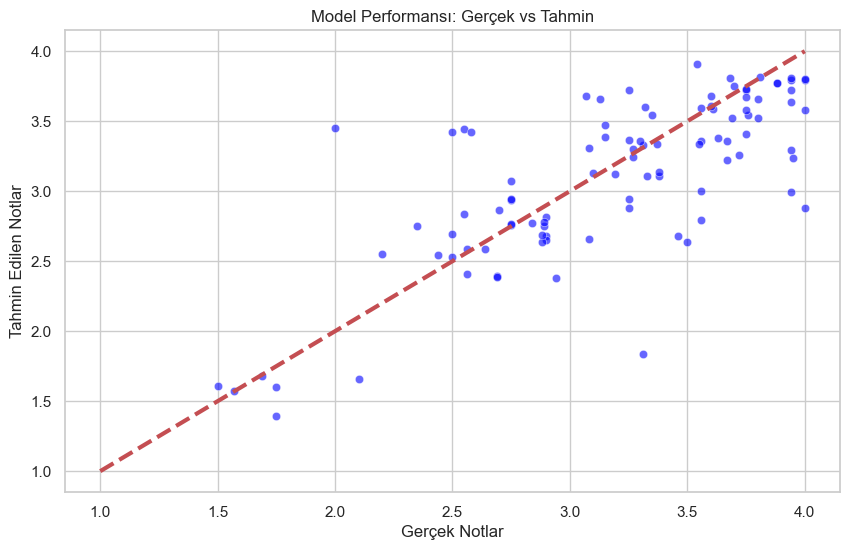

In [23]:
# --- Gerçek vs Tahmin Edilen Notlar Grafiği ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='blue')
# Mükemmel tahmin doğrusunu çiz (Kırmızı çizgi)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3)
plt.xlabel('Gerçek Notlar')
plt.ylabel('Tahmin Edilen Notlar')
plt.title('Model Performansı: Gerçek vs Tahmin')
plt.show()

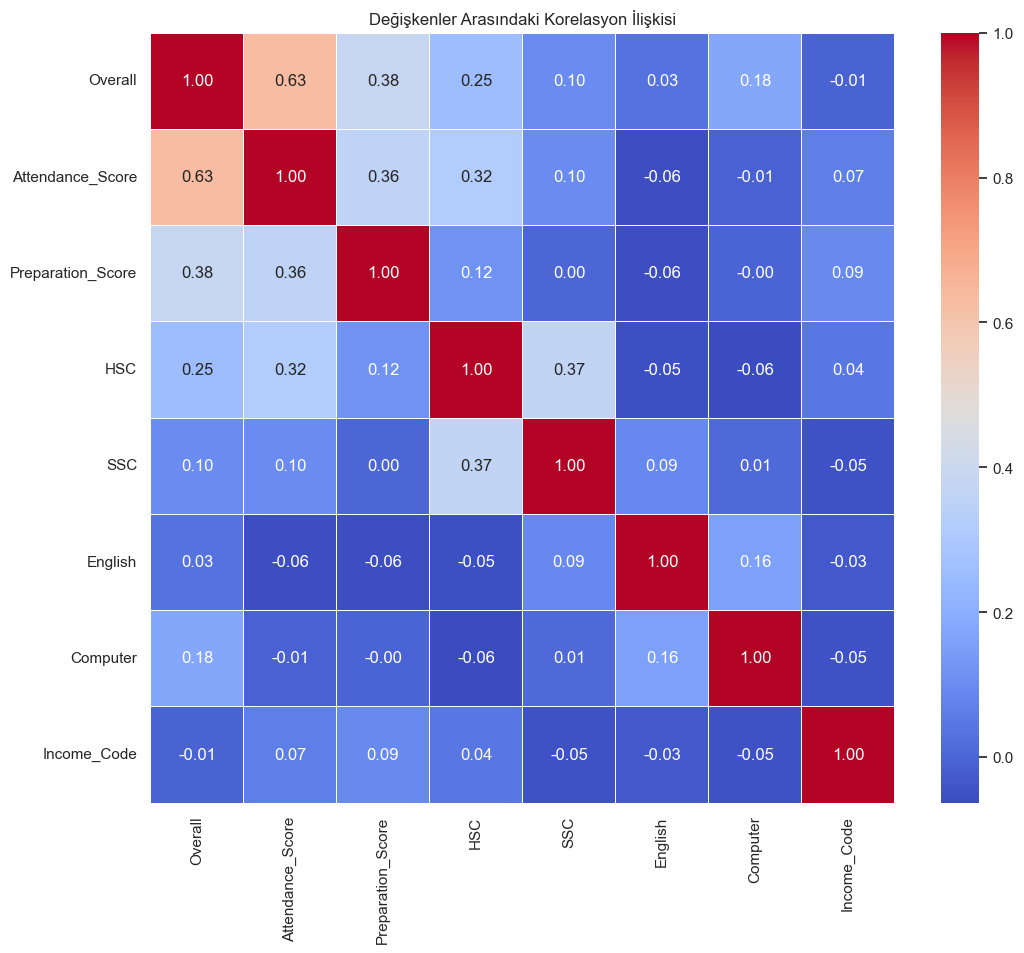

In [24]:
# --- Korelasyon Matrisi ---
# Sadece sayısal ve dönüştürülmüş sütunları alalım
corr_cols = ['Overall', 'Attendance_Score', 'Preparation_Score', 'HSC', 'SSC', 'English', 'Computer', 'Income_Code']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Değişkenler Arasındaki Korelasyon İlişkisi')
plt.show()

In [25]:
from sklearn.model_selection import GridSearchCV

# Denenecek parametreler
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Grid Search'ü başlat
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# En iyi sonuçları yazdır
print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"En İyi Skoru: {grid_search.best_score_:.4f}")

# En iyi modelle tekrar tahmin yap
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"Optimize Edilmiş R-Kare: {r2_score(y_test, y_pred_best):.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
En İyi Parametreler: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
En İyi Skoru: 0.5124
Optimize Edilmiş R-Kare: 0.5344


Gelişmiş Analizler

          Overall  Attendance_Score  Preparation_Score
Cluster                                               
0        3.217053          2.173684           0.563158
1        3.429386          2.623188           0.995169
2        2.611979          1.427083           0.093750


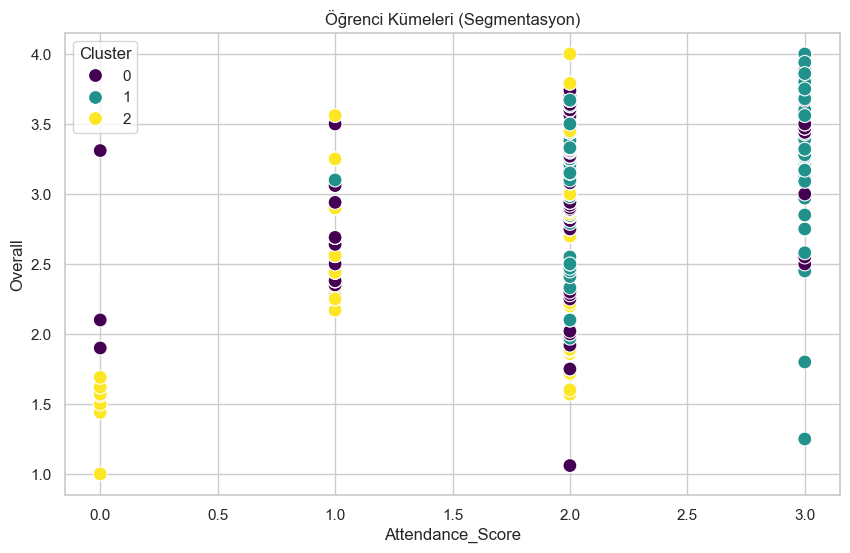

In [26]:
from sklearn.cluster import KMeans

# Sadece davranışsal verileri alalım (Devam, Çalışma, Oyun, Gelir)
cluster_features = df[['Attendance_Score', 'Preparation_Score', 'Income_Code', 'Gaming_Code']]

# 3 Gruba ayıralım (Örn: Başarılılar, Ortalar, Riskli Grup)
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(cluster_features)

# Grupların ortalamalarına bakalım
print(df.groupby('Cluster')[['Overall', 'Attendance_Score', 'Preparation_Score']].mean())

# Görselleştirme (Devam vs Not Ortalaması üzerinde grupları boyayalım)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Attendance_Score', y='Overall', hue='Cluster', data=df, palette='viridis', s=100)
plt.title('Öğrenci Kümeleri (Segmentasyon)')
plt.show()

Linear Regression R2 Skoru: 0.4249
Random Forest R2 Skoru: 0.5357
Gradient Boosting R2 Skoru: 0.5662


C:\Users\bberk\AppData\Local\Temp\ipykernel_9288\767912786.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')


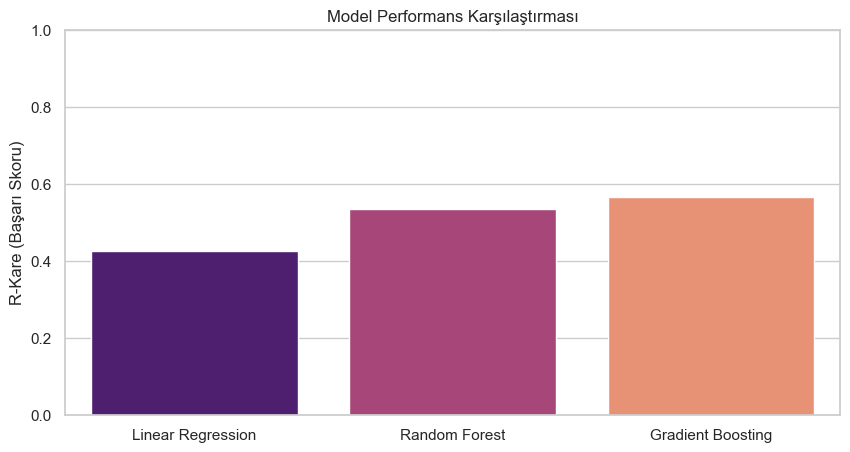

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# 1. Modelleri Tanımla
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# 2. Döngü ile Hepsini Eğit ve Test Et
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_temp = model.predict(X_test)
    score = r2_score(y_test, y_pred_temp)
    results[name] = score
    print(f"{name} R2 Skoru: {score:.4f}")

# 3. Sonuçları Görselleştir
plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='magma')
plt.title('Model Performans Karşılaştırması')
plt.ylabel('R-Kare (Başarı Skoru)')
plt.ylim(0, 1) # Skoru 0-1 arasına sabitle
plt.show()

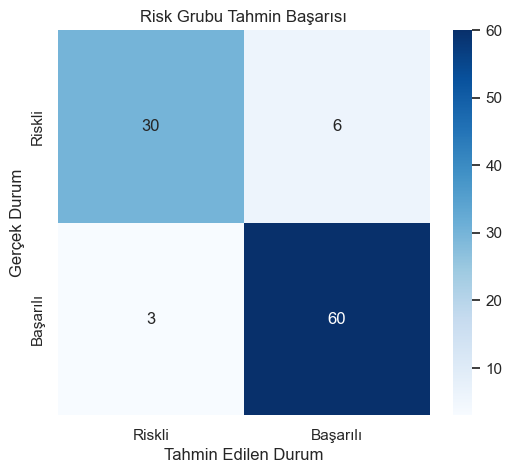

              precision    recall  f1-score   support

      Riskli       0.91      0.83      0.87        36
    Başarılı       0.91      0.95      0.93        63

    accuracy                           0.91        99
   macro avg       0.91      0.89      0.90        99
weighted avg       0.91      0.91      0.91        99



In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Hedef Değişkeni Kategorize Et (Eşik Değer: 3.00)
y_class = (df['Overall'] >= 3.00).astype(int) # 1: Başarılı, 0: Riskli

# Veriyi tekrar böl (Bu yeni hedef için)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42)

# 2. Sınıflandırma Modelini Eğit
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
y_pred_class = clf.predict(X_test_c)

# 3. Karmaşıklık Matrisi (Confusion Matrix)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test_c, y_pred_class), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Riskli', 'Başarılı'], yticklabels=['Riskli', 'Başarılı'])
plt.title('Risk Grubu Tahmin Başarısı')
plt.ylabel('Gerçek Durum')
plt.xlabel('Tahmin Edilen Durum')
plt.show()

# Detaylı Rapor
print(classification_report(y_test_c, y_pred_class, target_names=['Riskli', 'Başarılı']))

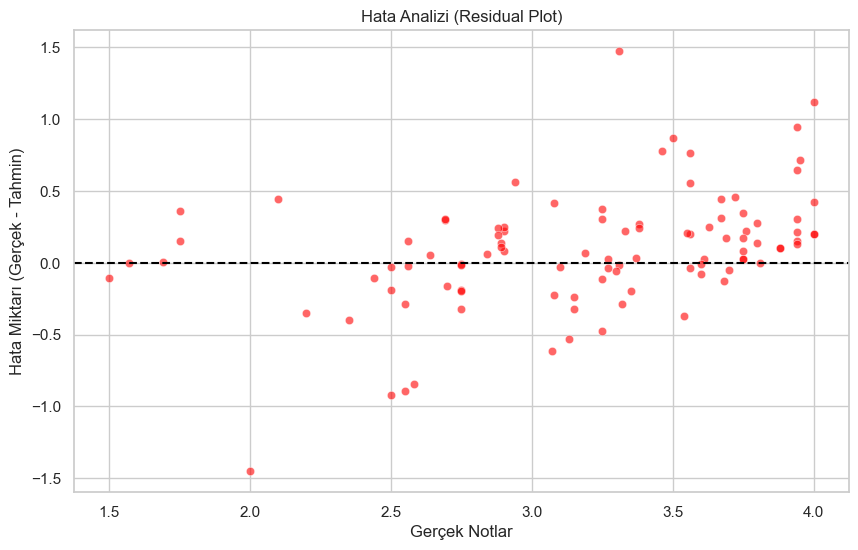

In [27]:
# Hata Paylarını (Residuals) Hesapla
residuals = y_test - y_pred # (Gerçek - Tahmin)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals, color='red', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--') # 0 Çizgisi (Hatasızlık)
plt.title('Hata Analizi (Residual Plot)')
plt.xlabel('Gerçek Notlar')
plt.ylabel('Hata Miktarı (Gerçek - Tahmin)')
plt.show()

In [ ]:
from ipywidgets import interact, widgets

# --- Canlı Tahmin Simülasyonu ---

def tahmin_et(Attendance, Preparation, Income, Department, Gaming, HSC, SSC):
    # 1. Girdileri Modele Uygun Hale Getir (Encoding)
    
    # Manuel Map işlemleri (Yukarıdaki sözlüklerin aynısı)
    att_map = {'Below 40%': 0, '40%-59%': 1, '60%-79%': 2, '80%-100%': 3}
    prep_map = {'0-1 Hour': 0, '2-3 Hours': 1, 'More than 3 Hours': 2}
    inc_map = {'Low (Below 15,000)': 0, 'Lower middle (15,000-30,000)': 1, 
               'Upper middle (30,000-50,000)': 2, 'High (Above 50,000)': 3}
    
    # Seçilen değerleri sayıya çevir
    att_score = att_map[Attendance]
    prep_score = prep_map[Preparation]
    inc_score = inc_map[Income]
    
    # Diğer kategorik veriler için (Örnek olarak sabit ortalama değerler atıyoruz)
    # Gerçek bir uygulamada bunları da LabelEncoder ile çevirmek gerekir.
    # Burada demo amaçlı Department ve Gaming için basit bir varsayım yapıyoruz.
    # (Not: Daha hassas olması için LabelEncoder'ı global tanımlayıp transform etmek gerekir)
    dept_code = 0  # Varsayılan
    game_code = 0  # Varsayılan
    
    # Girdi verisi oluştur (Eğitim sırasındaki sütun sırasıyla AYNI olmalı)
    # ['Attendance_Score', 'Preparation_Score', 'Income_Code', 'Department_Code', 
    #  'HSC', 'SSC', 'English', 'Computer', ...]
    
    # Basitleştirilmiş tahmin vektörü (Ortalama değerlerle doldurma)
    # Modelin beklediği tüm sütunları sağlamalıyız.
    # X_train.columns ile aynı sırada veri vermeliyiz.
    
    input_data = pd.DataFrame({
        'Attendance_Score': [att_score],
        'Preparation_Score': [prep_score],
        'Income_Code': [inc_score],
        'Department_Code': [0], # Demo için sabit
        'HSC': [HSC],
        'SSC': [SSC],
        'English': [4], # Ortalama bir değer
        'Computer': [3] # Ortalama bir değer
    })
    
    # Eksik sütunları (Hometown, Job, Extra vb.) eğitim setindeki ortalamalarla doldur
    # Bu kısım modelin hata vermemesi için kritiktir
    missing_cols = set(X_train.columns) - set(input_data.columns)
    for c in missing_cols:
        input_data[c] = 0 # Veya ortalama değer
        
    # Sütun sırasını eşitle
    input_data = input_data[X_train.columns]

    # Tahmin Yap
    pred_score = model.predict(input_data)[0]
    
    print(f"--- SİMÜLASYON SONUCU ---")
    print(f"Bu öğrencinin Tahmini Not Ortalaması (GPA): {pred_score:.2f} / 4.00")
    
    if pred_score < 2.5:
        print("⚠️ Durum: RİSKLİ (Akademik Destek Gerekli)")
    elif pred_score < 3.5:
        print("✅ Durum: İYİ (Standart Başarı)")
    else:
        print("🌟 Durum: MÜKEMMEL (Yüksek Başarı)")

# Arayüzü Oluştur
interact(tahmin_et, 
         Attendance=widgets.Dropdown(options=['Below 40%', '40%-59%', '60%-79%', '80%-100%'], value='80%-100%'),
         Preparation=widgets.Dropdown(options=['0-1 Hour', '2-3 Hours', 'More than 3 Hours'], value='2-3 Hours'),
         Income=widgets.Dropdown(options=['Low (Below 15,000)', 'Lower middle (15,000-30,000)', 'Upper middle (30,000-50,000)', 'High (Above 50,000)'], value='Lower middle (15,000-30,000)'),
         Department=widgets.fixed('Business'),
         Gaming=widgets.fixed('0-1 Hour'),
         HSC=widgets.FloatSlider(min=2.0, max=5.0, step=0.1, value=4.0, description='Lise Notu'),
         SSC=widgets.FloatSlider(min=2.0, max=5.0, step=0.1, value=4.5, description='Ortaokul Notu')
        );